In [1]:
import pandas as pd


url = "https://raw.githubusercontent.com/vbabashov/house-prices/refs/heads/main/data/raw/train.csv"
df = pd.read_csv(url)

df.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
import pandas as pd
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("\nData Types Count:\n", df.dtypes.value_counts())
print("\nTop Missing Value Columns:\n", df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Dataset Shape: (1460, 81)
Duplicate Rows: 0

Data Types Count:
 str        43
int64      35
float64     3
Name: count, dtype: int64

Top Missing Value Columns:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


there exist alot of nulls in our data and 0 duplicates

In [3]:
import pandas as pd

# Target Variable
target = ["SalePrice"]

# Numerical Features
num_continuous = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
]

num_discrete = [
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
    "MoSold",
    "YrSold",
]

# Combined Numerical Features list
numerical_features = num_continuous + num_discrete

# Nominal Categorical Features
nominal_features = [
    "Neighborhood",
    "MSZoning",
    "BldgType",
    "HouseStyle",
    "Foundation",
    "Exterior1st",
    "Exterior2nd",
    "RoofStyle",
    "SaleType",
    "SaleCondition",
    "Alley",
]

# Ordinal Categorical Features
ordinal_features = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "LotShape",
    "Utilities",
]

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

`target variable`

[Text(0.5, 1.0, 'Original SalePrice (Skew: 1.88)')]

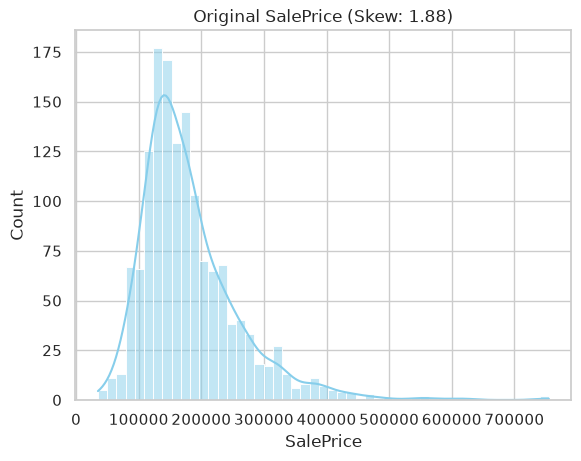

In [5]:
df["SalePrice"].skew()
sns.histplot(df["SalePrice"], kde=True, color='skyblue').set(title=f"Original SalePrice (Skew: {df['SalePrice'].skew():.2f})")

we have severe right skewness in our target variable        will need handling later with yeojhonson or even log works

`continous features`

In [6]:
df[num_continuous].describe()

,GrLivArea,LotArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageArea,LotFrontage,MasVnrArea
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1201.000000,1452.000000
mean,1515.463699,10516.828082,1057.429452,1162.626712,346.992466,472.980137,70.049958,103.685262
std,525.480383,9981.264932,438.705324,386.587738,436.528436,213.804841,24.284752,181.066207
min,334.000000,1300.000000,0.000000,334.000000,0.000000,0.000000,21.000000,0.000000
25%,1129.500000,7553.500000,795.750000,882.000000,0.000000,334.500000,59.000000,0.000000
50%,1464.000000,9478.500000,991.500000,1087.000000,0.000000,480.000000,69.000000,0.000000
75%,1776.750000,11601.500000,1298.250000,1391.250000,728.000000,576.000000,80.000000,166.000000
max,5642.000000,215245.000000,6110.000000,4692.000000,2065.000000,1418.000000,313.000000,1600.000000


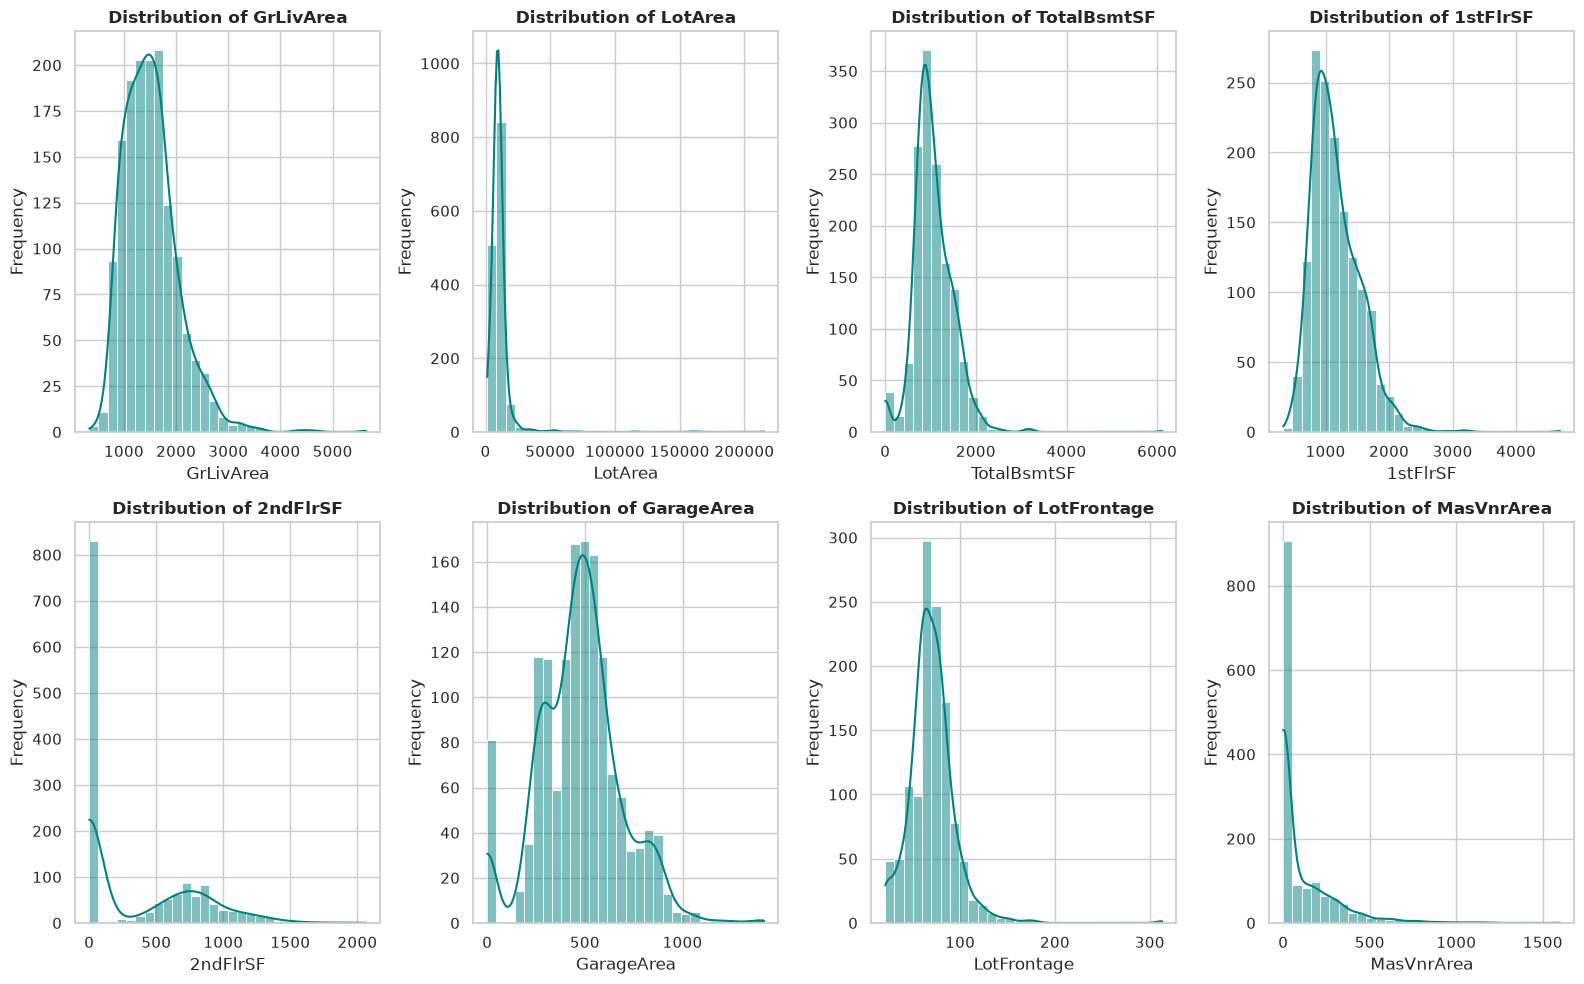

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_continuous):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal", bins=30)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

LotArea has a mean of 10,516 a median of 9,478 and a max of 215,245 high right skewness

Masvnr area has a median and 75th% of 166 with a max of 1600 highly skewed data as well, shows massive 0 infilation which makes it a good candidate for "hasmasvnr"

second floor also has a median of 0 and max of 2065 

for the GRlivArea the 75th% of homes are under 1.8k but max is at 5.6k, the author of the dataset DeanDeCock highlights that the data contains homes with GrLivArea > 4,000 sq ft that sold for unusually low prices

2nd floor is a primary candidate of "has2ndfloor" since the data spikes at 0 mostly

garage area exhibits a clusters or multipeak distributions at 1 car, 2car and 3 car sizes

`continous features vs target salesprice`

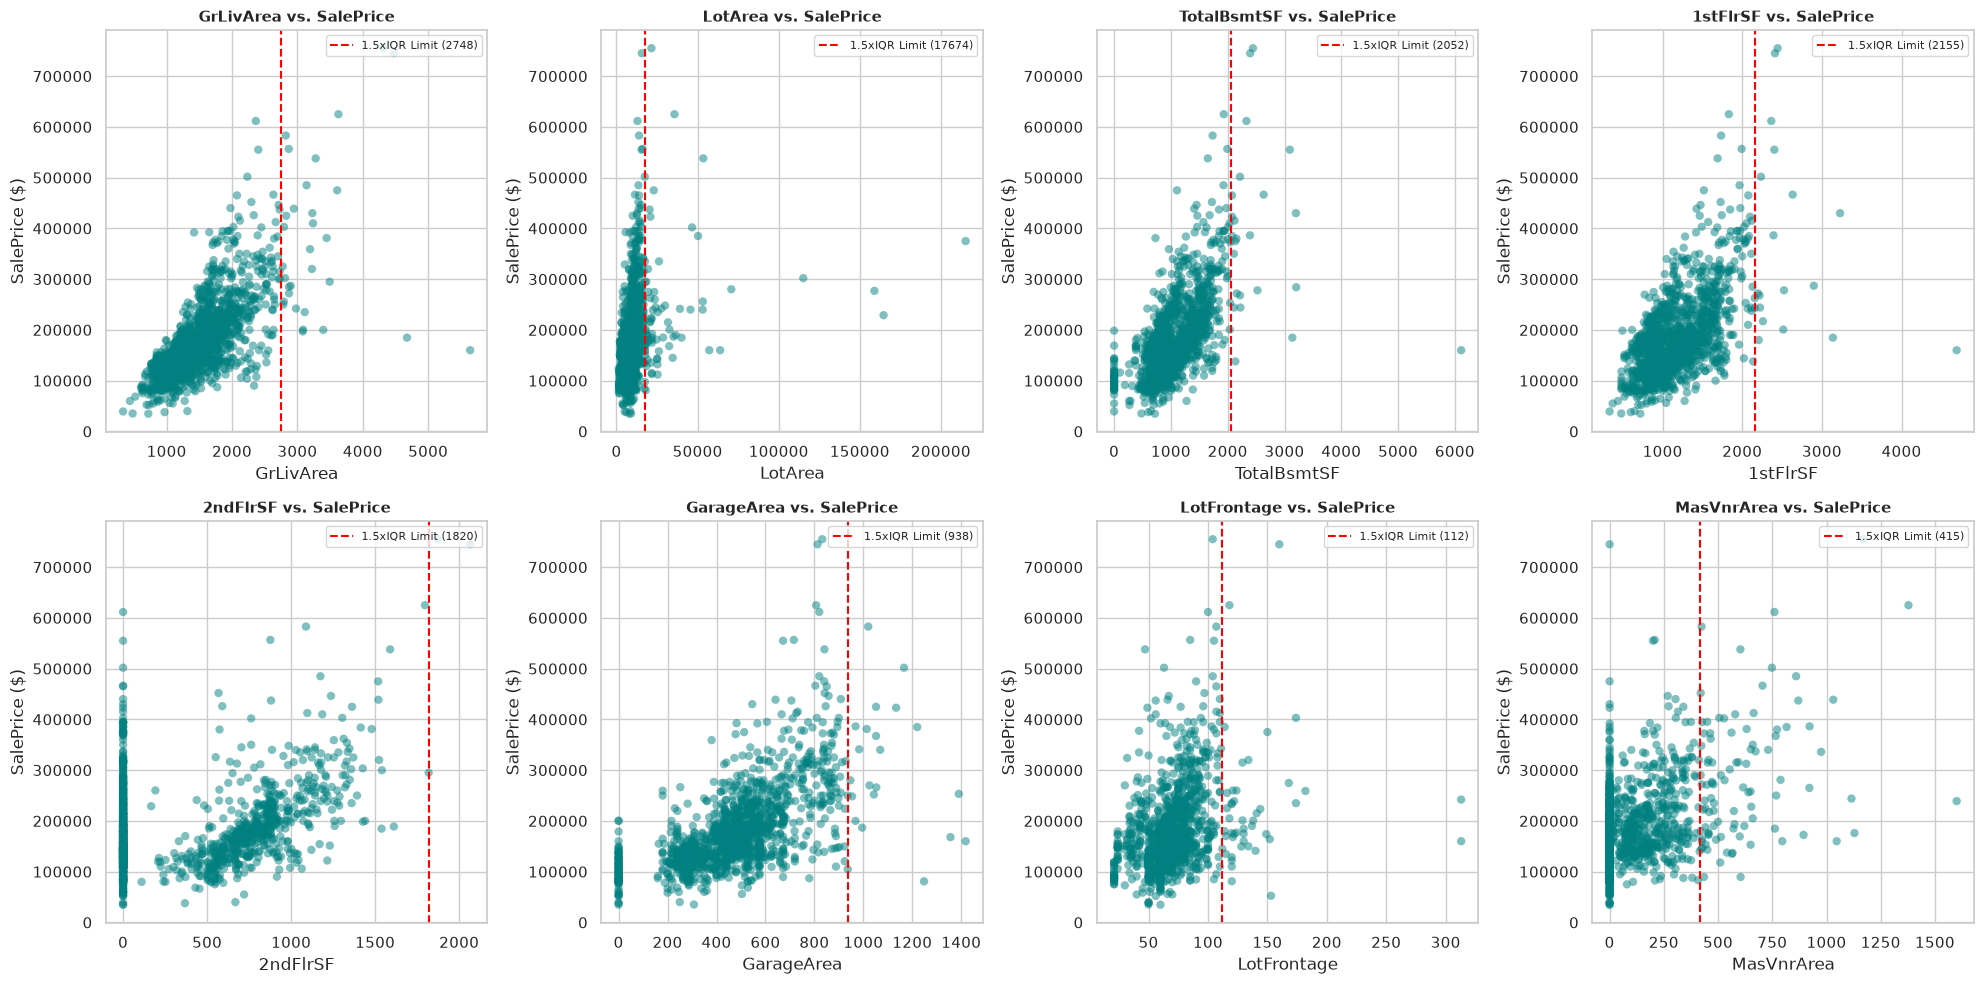

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Continuous features from your grid
num_continuous = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_continuous):
    if col in df.columns and "SalePrice" in df.columns:
        # Calculate IQR upper bound for the current feature
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr

        # Plot scatter
        sns.scatterplot(
            data=df,
            x=col,
            y="SalePrice",
            ax=axes[i],
            alpha=0.5,
            color="teal",
            edgecolor="none",
        )

        # Draw red dashed line at Upper Bound threshold
        axes[i].axvline(
            upper_bound,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"1.5xIQR Limit ({upper_bound:.0f})",
        )

        axes[i].set_title(f"{col} vs. SalePrice", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("SalePrice ($)")
        axes[i].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

here again we can see the GrLivArea above 4k we have some dots that feel off which DeanDeCock highlighted

further more strengthens the key takeaways that we included after seeing the skewness

`outliers for continous features`

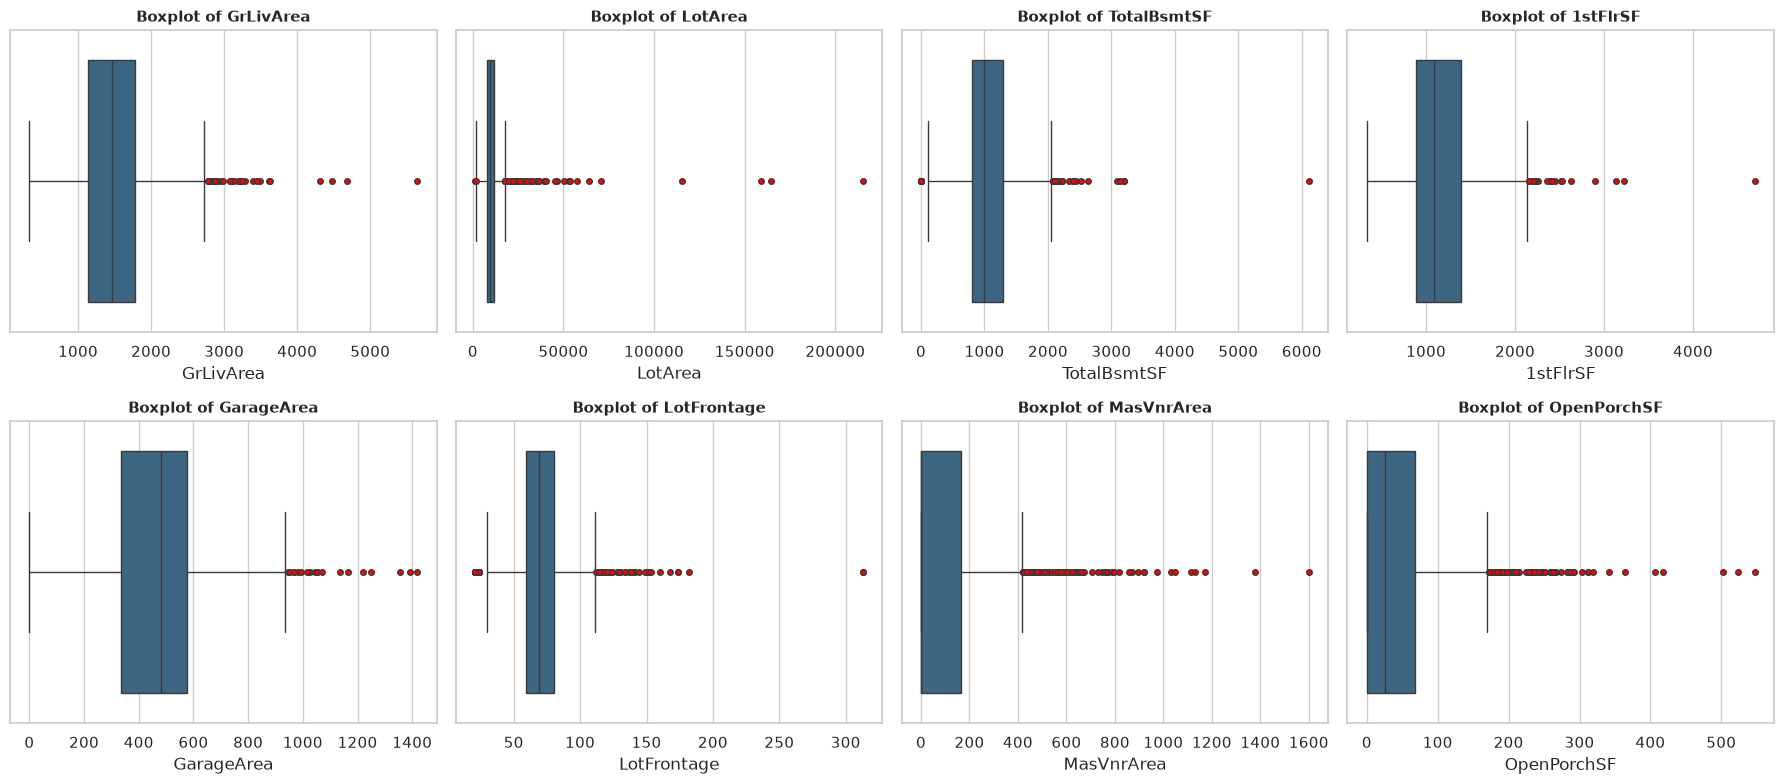

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Continuous features to check for extreme outliers
continuous_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
    "OpenPorchSF",
]

# Filter features that exist in df
valid_features = [col for col in continuous_features if col in df.columns]

# Create Box Plots Grid
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(valid_features):
    sns.boxplot(
        data=df, x=col, ax=axes[i], color="#31688e", flierprops={"markerfacecolor": "red", "markersize": 4}
    )
    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)

# Hide unused subplots if features < 8
for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
# Compute IQR Outliers
outlier_summary = []

for col in valid_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ].shape[0]
    pct_outliers = (outliers_count / len(df)) * 100

    outlier_summary.append(
        {
            "Feature": col,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Upper Bound": round(upper_bound, 2),
            "Outliers Count": outliers_count,
            "Outliers %": f"{pct_outliers:.2f}%",
        }
    )

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Q1,Q3,IQR,Upper Bound,Outliers Count,Outliers %
0,GrLivArea,1129.50,1776.75,647.25,2747.62,31,2.12%
1,LotArea,7553.50,11601.50,4048.00,17673.50,69,4.73%
2,TotalBsmtSF,795.75,1298.25,502.50,2052.00,61,4.18%
3,1stFlrSF,882.00,1391.25,509.25,2155.12,20,1.37%
4,GarageArea,334.50,576.00,241.50,938.25,21,1.44%
5,LotFrontage,59.00,80.00,21.00,111.50,88,6.03%
6,MasVnrArea,0.00,166.00,166.00,415.00,96,6.58%
7,OpenPorchSF,0.00,68.00,68.00,170.00,77,5.27%


as officially recommended by DeanDeCock dropping rows where GrLivArea > 4000 removes non typical/partial sales 

TotalBsmtSF Features an extreme outlier sitting at 6000+sqft (which matches the 5000+sqft GrLivArea outlier) and dropping the extreme GrLivArea usually drops the TotalBsmtSF outlier with it

LotArea and LotFrontage outliers are legitement and needs handling using yeo jhonson or log

the MasVnr and OpenPorch are legit data but the Q1 is squashed to 0 due to alot of houses not having any porches or masonry veneers

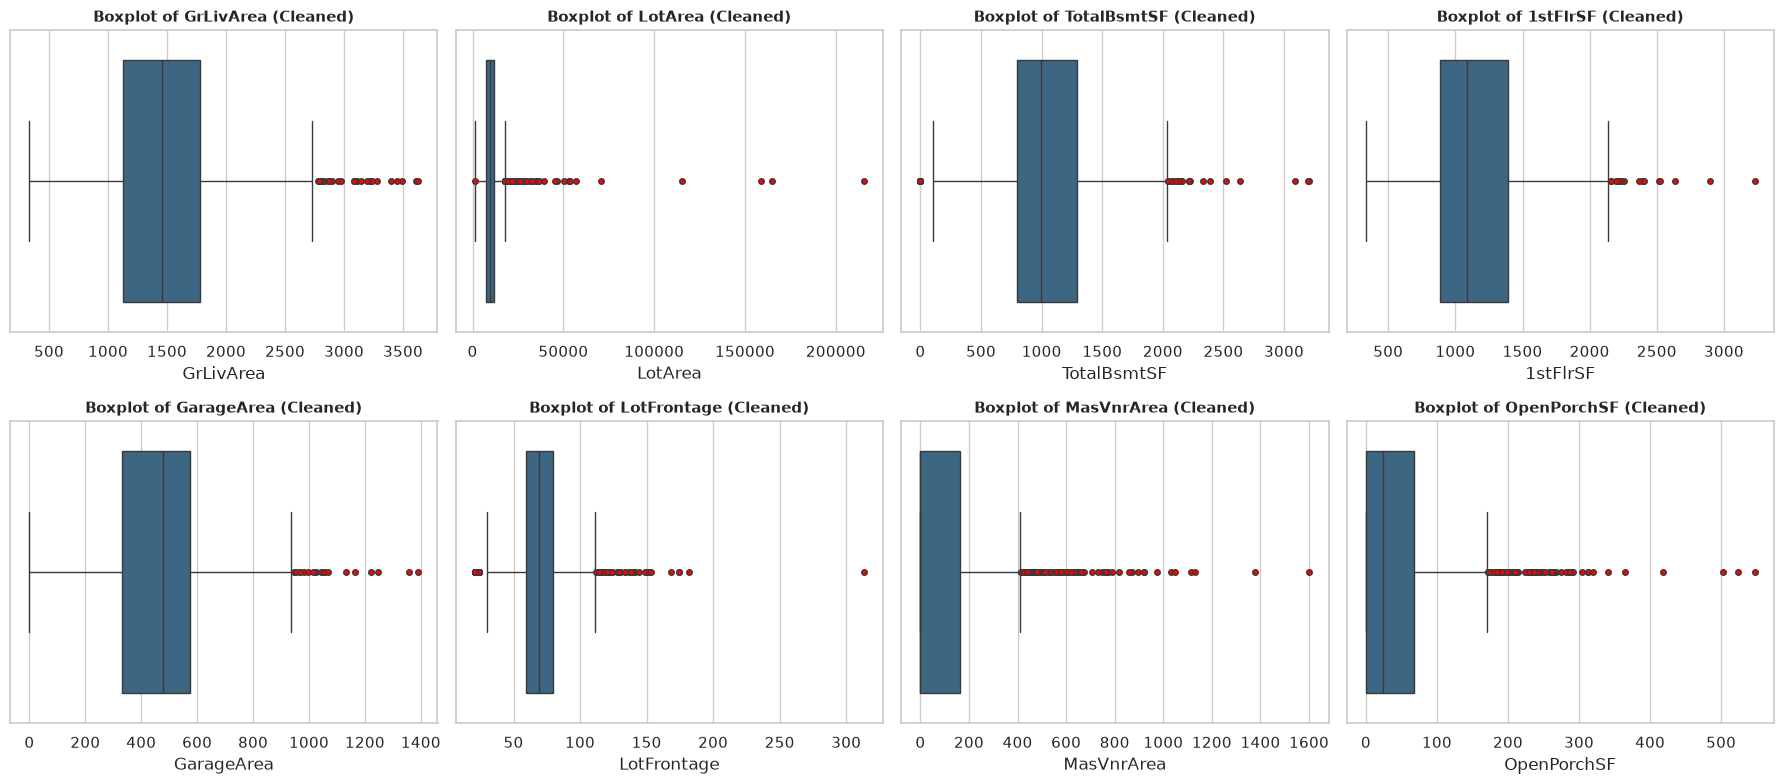

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out extreme leverage outliers (GrLivArea >= 4000)
df_cleaned = df[df["GrLivArea"] < 4000].copy()

# 2. Continuous features list
valid_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea",
    "OpenPorchSF",
]

# 3. Plot updated Box Plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(valid_features):
    if col in df_cleaned.columns:
        sns.boxplot(
            data=df_cleaned,
            x=col,
            ax=axes[i],
            color="#31688e",
            flierprops={"markerfacecolor": "red", "markersize": 4},
        )
        axes[i].set_title(
            f"Boxplot of {col} (Cleaned)", fontsize=11, fontweight="bold"
        )
        axes[i].set_xlabel(col)

# Hide any extra empty subplots
for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


after dropping the extreme GrLivArea 

GrLivArea and TotalBsmSF leverage removed the extreme outliers have been removed

lot area and lotfrontage have natural skewness

the rest of the data roughly stayed the same


`discrete features`

In [12]:
df[num_discrete].describe()

,YearBuilt,YearRemodAdd,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,MoSold,YrSold
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1971.267808,1984.865753,1.565068,0.382877,2.866438,6.517808,0.613014,1.767123,6.321918,2007.815753
std,30.202904,20.645407,0.550916,0.502885,0.815778,1.625393,0.644666,0.747315,2.703626,1.328095
min,1872.000000,1950.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,2006.000000
25%,1954.000000,1967.000000,1.000000,0.000000,2.000000,5.000000,0.000000,1.000000,5.000000,2007.000000
50%,1973.000000,1994.000000,2.000000,0.000000,3.000000,6.000000,1.000000,2.000000,6.000000,2008.000000
75%,2000.000000,2004.000000,2.000000,1.000000,3.000000,7.000000,1.000000,2.000000,8.000000,2009.000000
max,2010.000000,2010.000000,3.000000,2.000000,8.000000,14.000000,3.000000,4.000000,12.000000,2010.000000


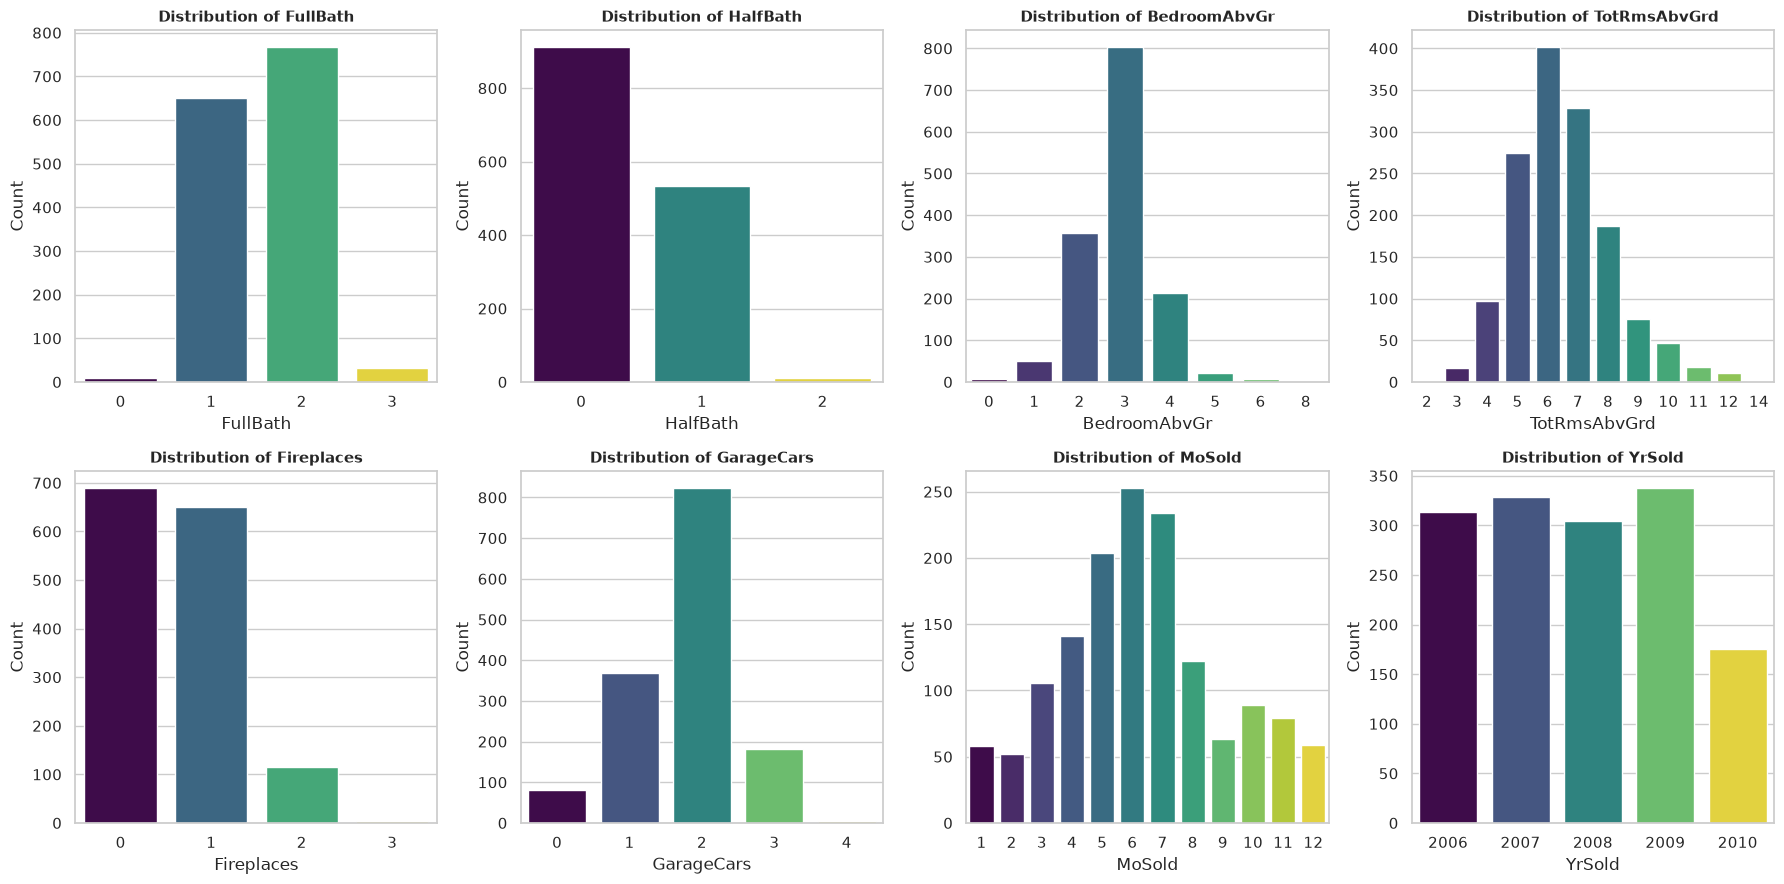

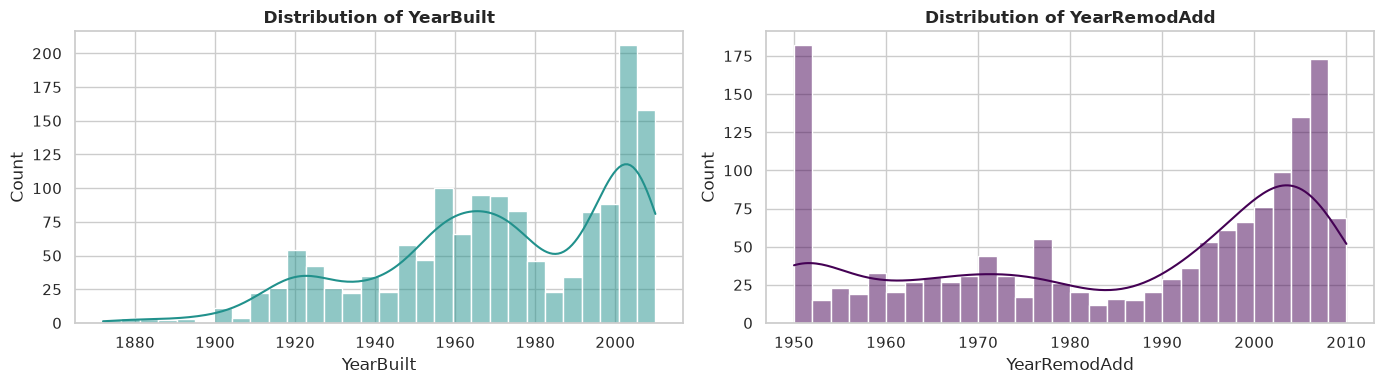

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean list without year features in countplot
discrete_features = [
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
    "MoSold",
    "YrSold",
]

# Grid for discrete count features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(discrete_features):
    # Added hue=col and legend=False to fix the Seaborn v0.14+ deprecation warning
    sns.countplot(
        data=df, x=col, hue=col, ax=axes[i], palette="viridis", legend=False
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Separate Histograms for Year Features (prevents squished x-axis labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["YearBuilt"], kde=True, ax=axes[0], color="#21918c", bins=30)
axes[0].set_title("Distribution of YearBuilt", fontweight="bold")

sns.histplot(
    df["YearRemodAdd"], kde=True, ax=axes[1], color="#440154", bins=30
)
axes[1].set_title("Distribution of YearRemodAdd", fontweight="bold")

plt.tight_layout()
plt.show()

no nulls on numerical discrete features, the data set lies between 2006 and 2010

raw year numbers arent ideal for linear ML models cols like houseage and remodage might be added

full bath and half bath can be combined into 1 feature

cyclic encoding might be considered for the yr/mo sold features

standard 3 bedroom dominates 

totrmsabv average follows a noral distribution centered at 6

as for garage 2 car slots is the standard for most homes

fire places is a really good candidate of being replaced by a has fireplace as its mostly 0 or 1 with little to nothing above


as for the year built, shows a minor surge at 1920 and post WWII housing boom around 1950-1970 and a massive expansion from 2000-2007 before the 2008 financial crisis, will probably make a new col HouseAge = yrsold-yrblt to avoid confusion in linear models 

as for the yearrmodadd, 1950 has a spike cuz no remods where set to 1950 in this dataset starting from 1990 to 2008 an upward trend in remodelling can be noticed, will probably make RemodAge = yrsold - yearremodadd to avoid cofusion in linear models

MoSold  show market seasonality in months 5 6 7 real estate drop sharply at november and till feb next year (consider cyclic encoding)

annual sales are evenly distributed 2006-2009 and drops at 2010 simply because the data collection endded at july

`ordinal features`

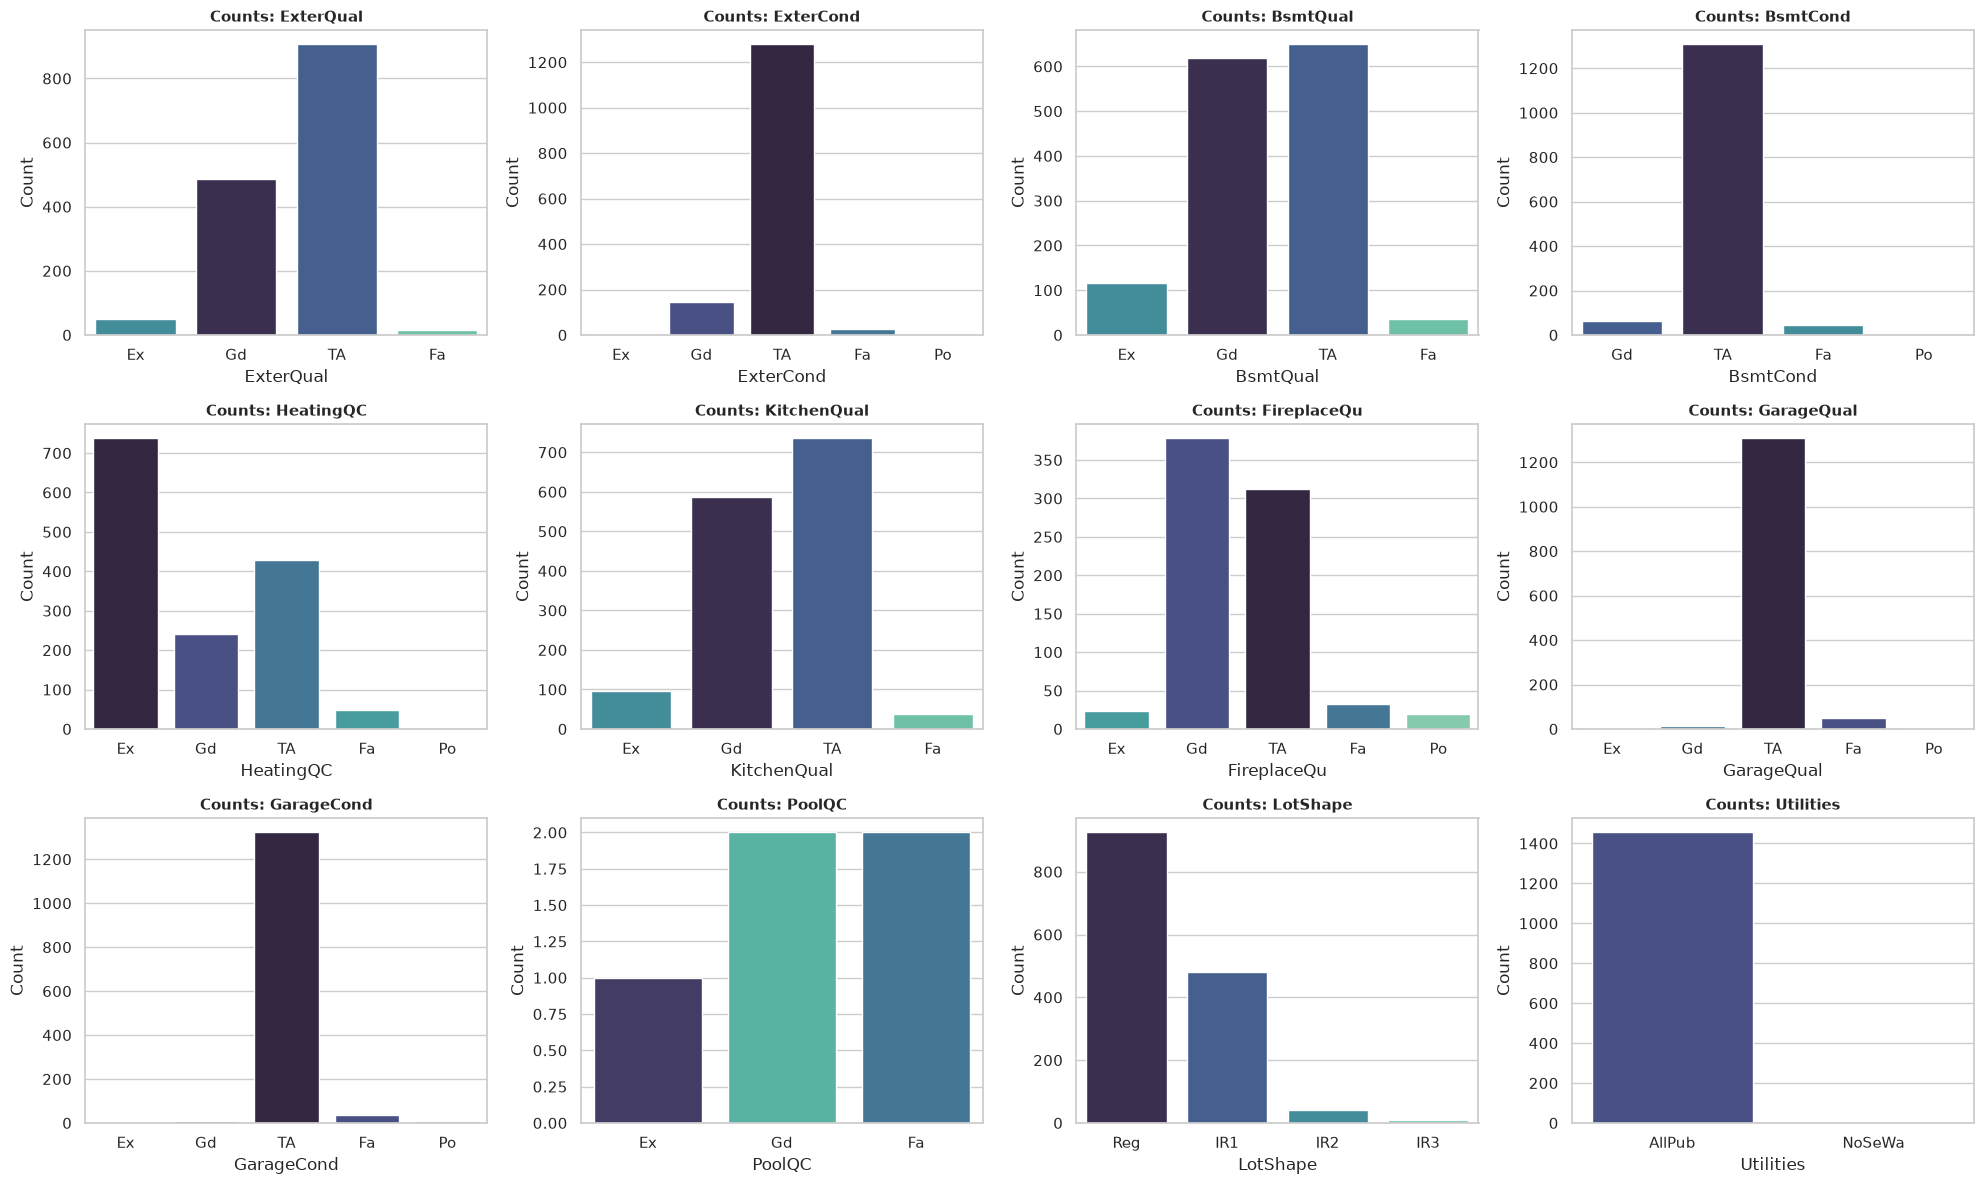

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Standard quality rating hierarchy
rating_order = ["Ex", "Gd", "TA", "Fa", "Po"]

# Create a 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(ordinal_features):
    if col in df_cleaned.columns:
        # Determine order present in data
        unique_vals = df_cleaned[col].dropna().unique()
        col_order = [o for o in rating_order if o in unique_vals] + [
            o for o in unique_vals if o not in rating_order
        ]

        sns.countplot(
            data=df_cleaned,
            x=col,
            order=col_order,
            ax=axes[i],
            palette="mako",
            hue=col,
            legend=False,
        )
        axes[i].set_title(f"Counts: {col}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

# Hide extra subplots
for j in range(len(ordinal_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

severe class imabalnce, utitlies is only all pub, garageQual,garageCond,BsmtCond and extrCond are dominated by TA almost 90%+ 

exterqual , bsmt qual , heatingqual, kitchen qual, probably the most useful predictors for our model

poolqc has only 7 counts 



fire place has total count of around 750

`nominal features`

my goal is to indetify high caridnality, class distribution and variance aganist salesprice

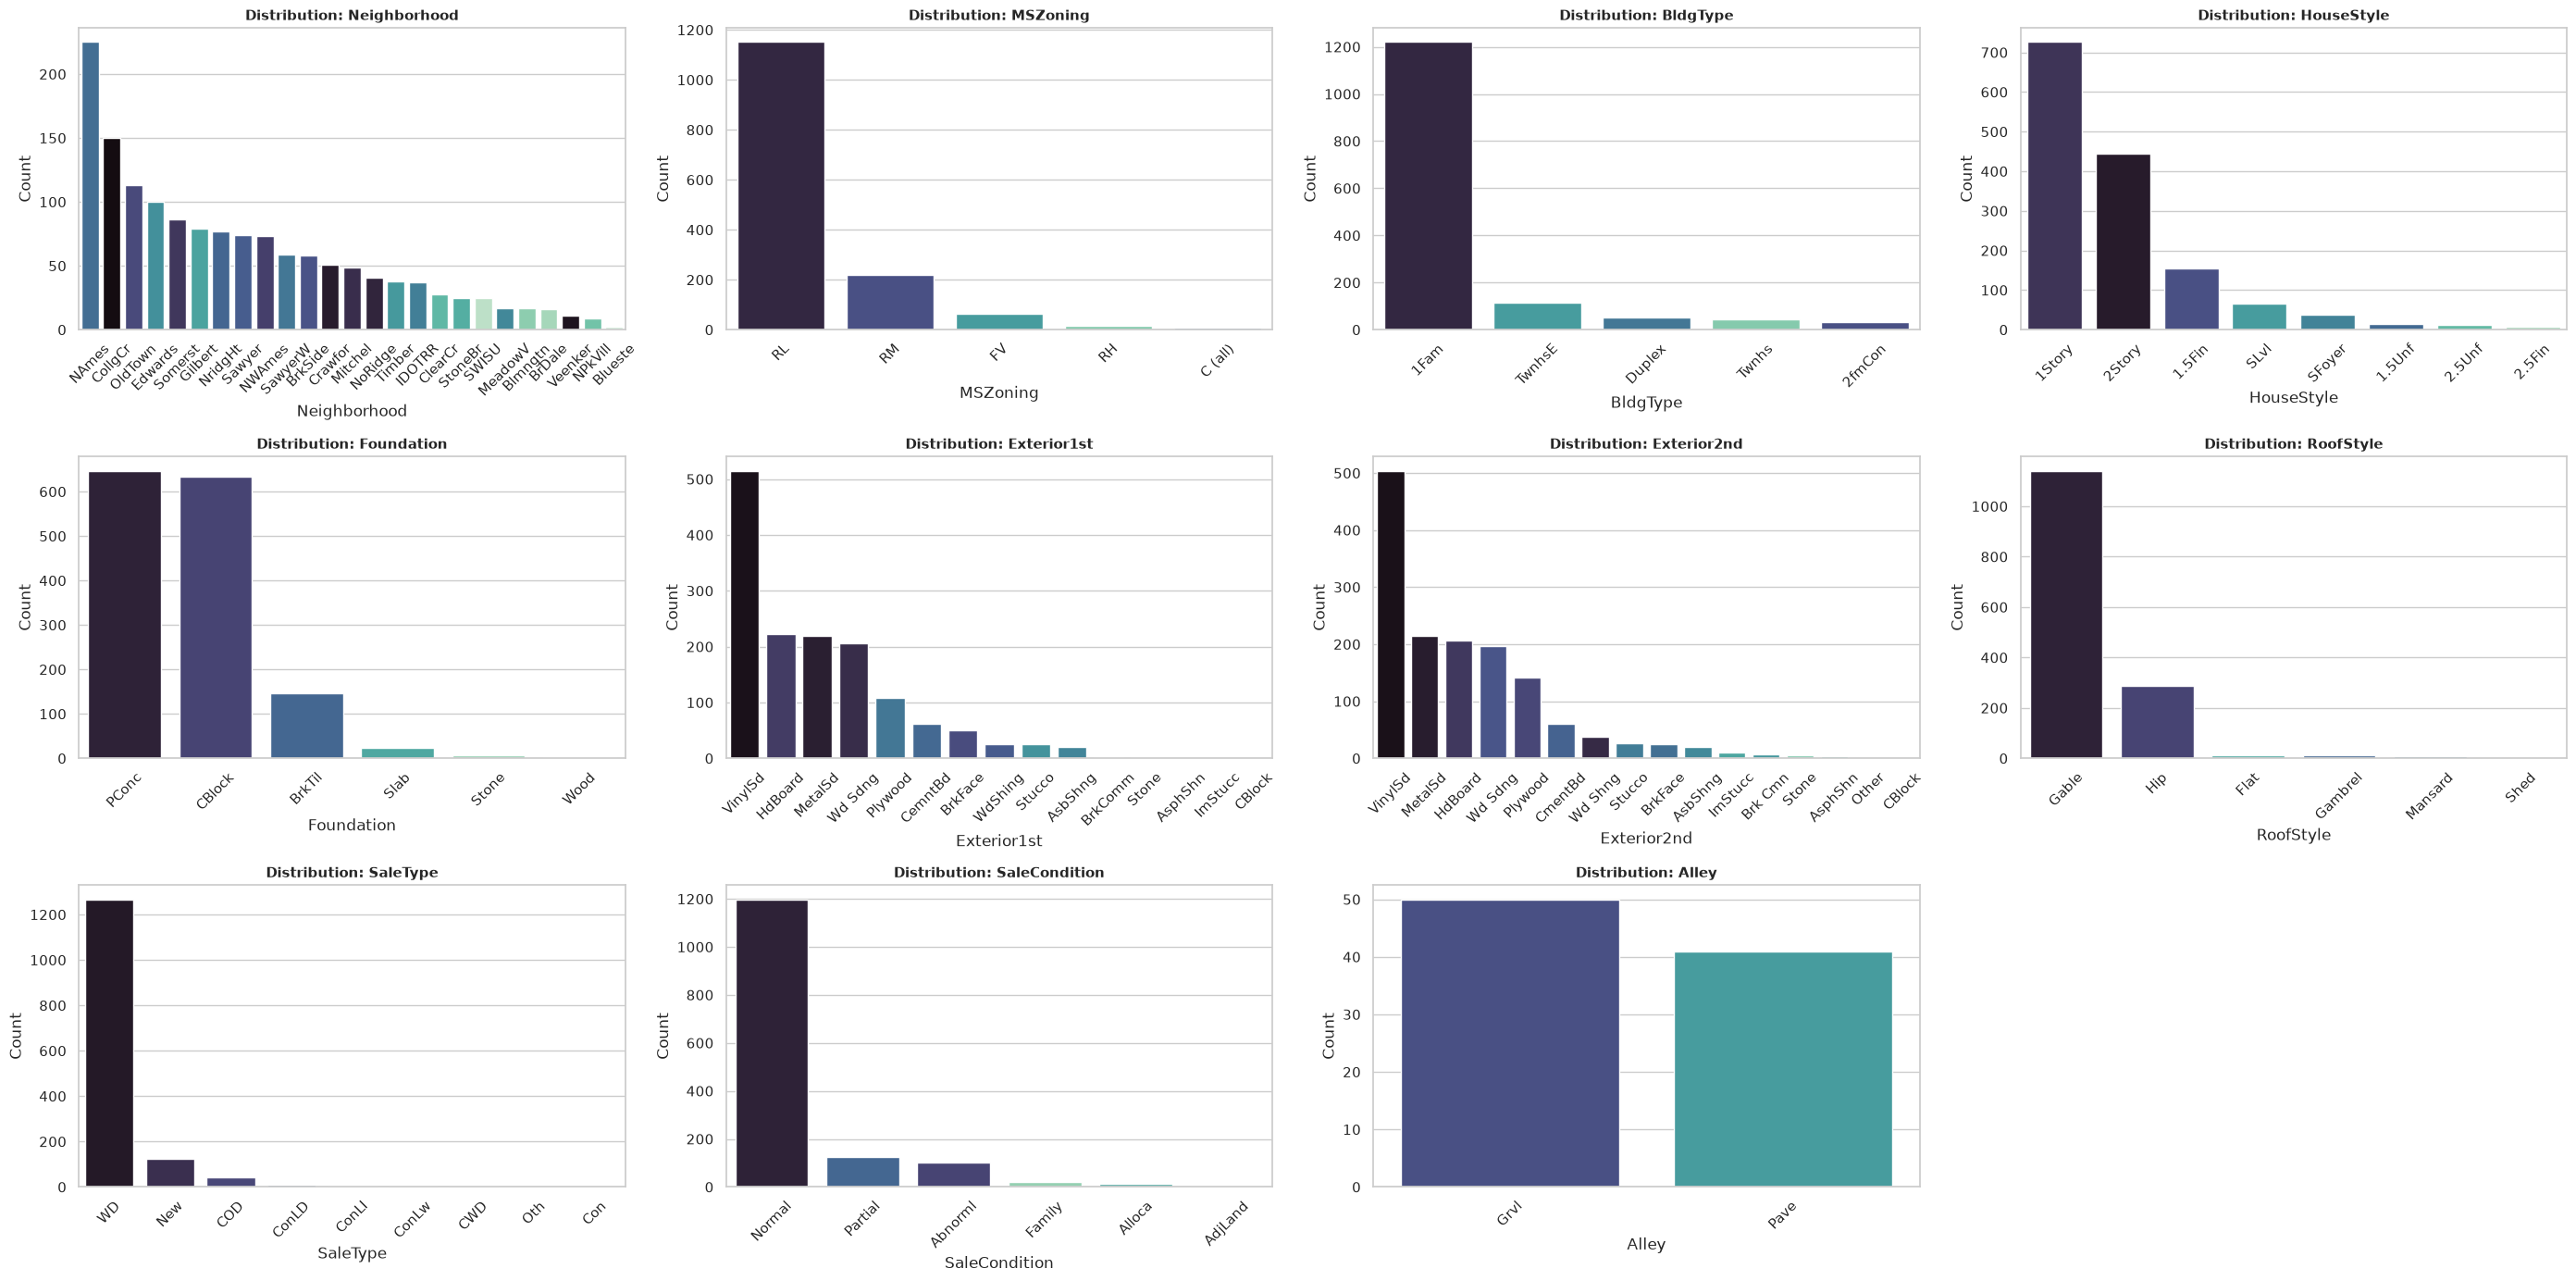

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

nominal_features = [
    "Neighborhood",
    "MSZoning",
    "BldgType",
    "HouseStyle",
    "Foundation",
    "Exterior1st",
    "Exterior2nd",
    "RoofStyle",
    "SaleType",
    "SaleCondition",
    "Alley",
]

# Grid setup (3x4 for 11 features)
fig, axes = plt.subplots(3, 4, figsize=(28, 14))
axes = axes.flatten()

for i, col in enumerate(nominal_features):
    if col in df.columns:
        # Sort categories by frequency
        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=order,
            ax=axes[i],
            palette="mako",
            hue=col,
            legend=False,
        )
        axes[i].set_title(f"Distribution: {col}", fontsize=11, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

# Remove the empty 12th subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

for sale type, sale condition, mszoning, bldgtype, rooftype we have severe class imbalance, one hot encoding will make cols with little to no variance

high cardinality features: neighborhood, exterior1st, exterior2nd, will probably target encode these mapping neighborhoods to their median saleprice

alley has so many nulls

`correlation analysis`

i dont think its the easiest to read a correlation matrix with so many features


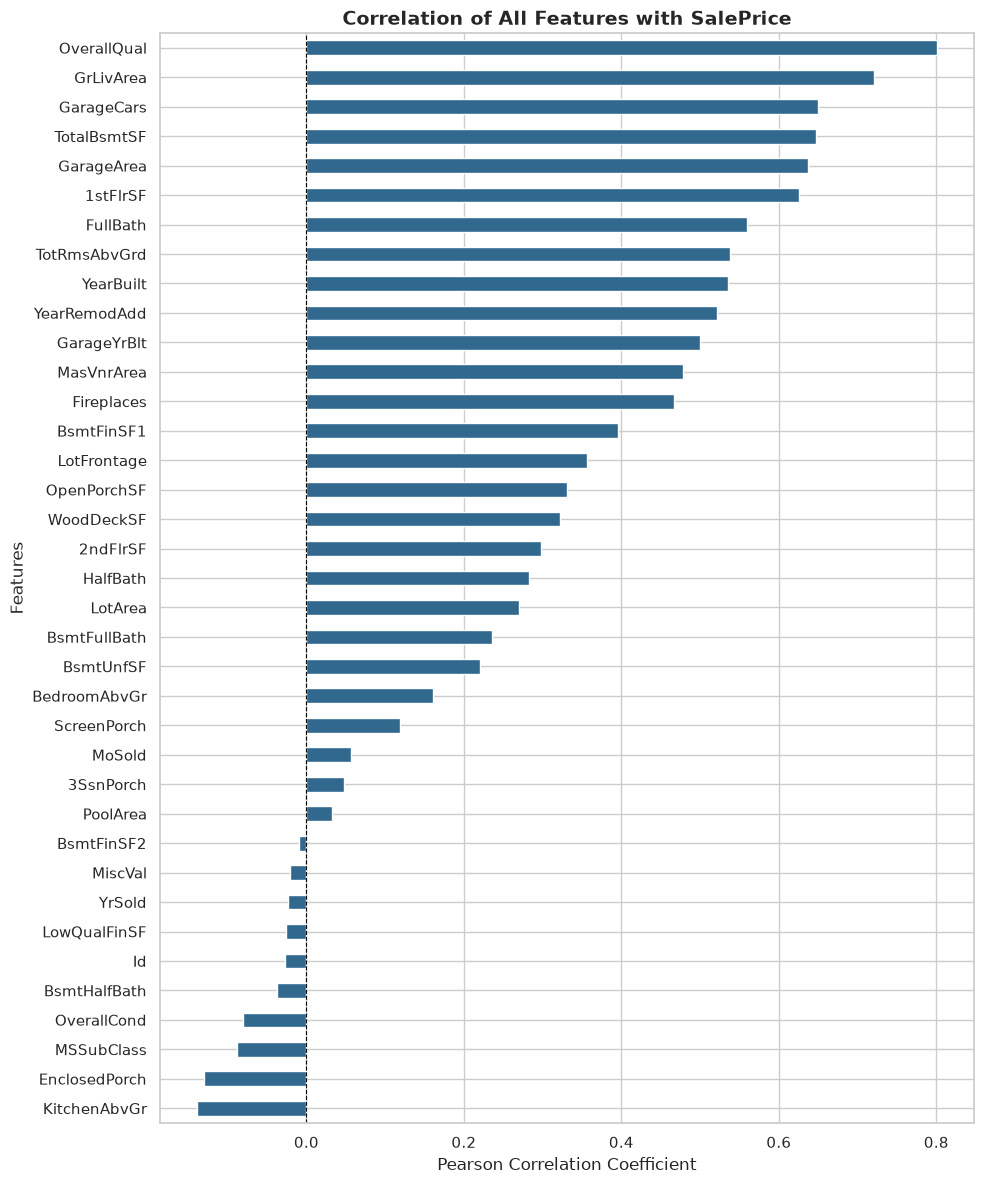

In [16]:
# Calculate correlation of all numeric features with SalePrice
saleprice_corr = (
    df_cleaned.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=True)
)

# Plot horizontal bar chart
plt.figure(figsize=(10, 12))
saleprice_corr.plot(kind="barh", color="#31688e")

plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlation of All Features with SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

overallqual and grlivarea are the most dominant in the dataset, they are the strongest drivers for salesprice

garagecars,garagearea,totalbsmtsf,1stflrsf all sti strongly correlated with salesprice

yrsold and monthsold have low correlation with salesprice because its cyclic and not a linear realation

pool area and porch has very low as well because most of these cols are straight zeros

kirchenabvgr and enclosed proch are highly negative because usually more than 1 kitchen signals multi-family/split properties which tend to sell for less per unit and older homes tend to have enclosed porches instead of modern open decks 

`house analysis`

In [17]:
df["SalePrice"].describe().apply(lambda x: round(x, 2))

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

mean is 180k while median is 163k which confirms the right skewness

In [18]:
min_house = df.loc[df['SalePrice'].idxmin()]
max_house = df.loc[df['SalePrice'].idxmax()]
print(f"Lowest Price House  -> ID: {min_house['Id']} | Price: ${min_house['SalePrice']:,}")
print(f"Highest Price House -> ID: {max_house['Id']} | Price: ${max_house['SalePrice']:,}")

Lowest Price House  -> ID: 496 | Price: $34,900
Highest Price House -> ID: 692 | Price: $755,000


In [19]:
top_5_pct = df[df['SalePrice'] >= df['SalePrice'].quantile(0.95)]
top_5_pct[['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']].describe().T[['mean', '50%', 'min', 'max']]

,mean,50%,min,max
GrLivArea,2421.013699,2364.0,1419.0,4476.0
OverallQual,8.657534,9.0,7.0,10.0
TotalBsmtSF,1747.616438,1746.0,728.0,3200.0
GarageCars,2.849315,3.0,2.0,3.0
YearBuilt,1998.219178,2005.0,1892.0,2010.0


the rating falls between 7-9 proving high quality is a very important feature (very intuitive as well)

massive sizes generally, the garages for 3 cars on average and mostly built recently with median of 2005

`neighborhood analysis`

In [20]:
# 1. Group and calculate describe statistics
neigh_stats = df.groupby("Neighborhood")["SalePrice"].describe()

# 2. Sort the entire dataframe by 'mean' in descending order
neigh_stats_sorted = neigh_stats.sort_values(by="mean", ascending=False)

# Top 3 most expensive neighborhoods
print("=== Top 3 Most Expensive Neighborhoods ===")
print(neigh_stats_sorted.head(3).round(2))

print("\n" + "="*60 + "\n")

# Bottom 3 least expensive neighborhoods
print("=== Bottom 3 Least Expensive Neighborhoods ===")
print(neigh_stats_sorted.tail(3).round(2))

print("\n" + "="*60 + "\n")

# Most frequent neighborhood
most_frequent = neigh_stats.sort_values(by="count", ascending=False).head(1)
print(f"Most Frequent Neighborhood: {most_frequent.index[0]} ({int(most_frequent['count'].values[0])} houses)")

=== Top 3 Most Expensive Neighborhoods ===
              count       mean        std       min       25%       50%  \
Neighborhood                                                              
NoRidge        41.0  335295.32  121412.66  190000.0  265000.0  301500.0   
NridgHt        77.0  316270.62   96392.54  154000.0  253293.0  315000.0   
StoneBr        25.0  310499.00  112969.68  170000.0  213500.0  278000.0   

                   75%       max  
Neighborhood                      
NoRidge       341000.0  755000.0  
NridgHt       374000.0  611657.0  
StoneBr       377426.0  556581.0  


=== Bottom 3 Least Expensive Neighborhoods ===
              count       mean       std      min      25%       50%  \
Neighborhood                                                           
BrDale         16.0  104493.75  14330.18  83000.0  91000.0  106000.0   
IDOTRR         37.0  100123.78  33376.71  34900.0  81000.0  103000.0   
MeadowV        17.0   98576.47  23491.05  75000.0  83500.0   88000.0 

neighborhoods NoRidge NridgHt StoneBr has are the top 3 neighborhoods in when it comes to prices, while brdale idotrr adn meadowv

NAmes has the most number of houses 225 houses 

ofcourse neighborhoods appear to have a strong relation with salesprice

`Time-Based Analysis`

In [21]:
# Group by Month Sold (MoSold) to calculate average price and total sales count
monthly_stats = (
    df.groupby("MoSold")["SalePrice"]
    .agg(["mean", "count"])
    .sort_values(by="mean", ascending=False)
)

# Map month numbers (1-12) to full month names for readability
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}
monthly_stats.index = monthly_stats.index.map(month_names)

# 1 & 2. Months with Highest and Lowest Average Sale Price
highest_price_month = monthly_stats.head(1)
lowest_price_month = monthly_stats.tail(1)

print("=== 1. Month with Highest Average Sale Price ===")
print(
    f"{highest_price_month.index[0]}: ${highest_price_month['mean'].values[0]:,.2f}"
)

print("\n=== 2. Month with Lowest Average Sale Price ===")
print(
    f"{lowest_price_month.index[0]}: ${lowest_price_month['mean'].values[0]:,.2f}"
)

print("\n" + "=" * 50 + "\n")

# 3. Month with Highest Sales Volume (Count)
highest_volume_month = monthly_stats.sort_values(
    by="count", ascending=False
).head(1)
print("=== 3. Month with Highest Number of House Sales ===")
print(
    f"{highest_volume_month.index[0]}: {int(highest_volume_month['count'].values[0])} sales"
)



=== 1. Month with Highest Average Sale Price ===
September: $195,683.21

=== 2. Month with Lowest Average Sale Price ===
April: $171,503.26


=== 3. Month with Highest Number of House Sales ===
June: 253 sales


most houses are sold in june, highest average in june and lowest in april 

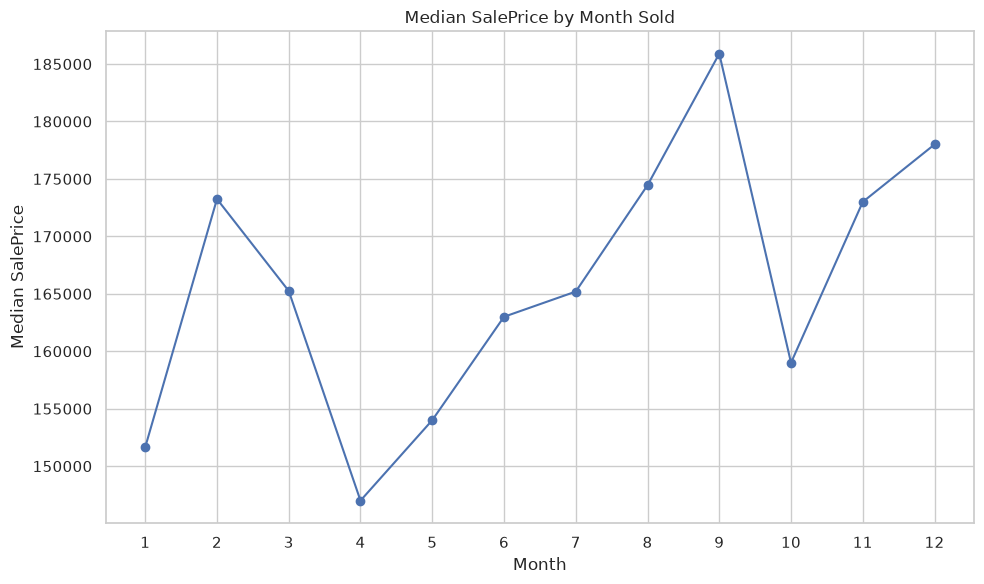

In [22]:
import matplotlib.pyplot as plt

# Calculate median SalePrice grouped by MoSold
monthly_median = df.groupby("MoSold")["SalePrice"].median()

# Create plot matching your image specifications
plt.figure(figsize=(10, 6))
plt.plot(
    monthly_median.index,
    monthly_median.values,
    marker="o",
    linestyle="-",
    linewidth=1.5,
)

# Titles and axis labels
plt.title("Median SalePrice by Month Sold")
plt.xlabel("Month")
plt.ylabel("Median SalePrice")

# Ensure all months (1–12) are shown on x-axis
plt.xticks(range(1, 13))

# Display grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
import numpy as np
from IPython.display import display

# Ensure engineered features are added directly to df
df["TotalBath"] = (
    df["FullBath"]
    + (0.5 * df["HalfBath"])
    + df["BsmtFullBath"]
    + (0.5 * df["BsmtHalfBath"])
)

df["HasBsmt"] = np.where(df["TotalBsmtSF"] > 0, "Yes", "No")

# 1. Bedrooms vs. SalePrice
display(
    df.groupby("BedroomAbvGr")["SalePrice"]
    .agg(["count", "median", "mean"])
    .style.format({"median": "${:,.0f}", "mean": "${:,.0f}"})
)

# 2. Bathrooms vs. SalePrice
display(
    df.groupby("TotalBath")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 3. Overall Quality vs. SalePrice
display(
    df.groupby("OverallQual")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 4. Garage Capacity vs. SalePrice
display(
    df.groupby("GarageCars")["SalePrice"]
    .agg(["count", "median"])
    .style.format({"median": "${:,.0f}"})
)

# 5. Basement Impact
display(
    df.groupby("HasBsmt")["SalePrice"]
    .agg(["count", "mean", "median"])
    .style.format({"mean": "${:,.0f}", "median": "${:,.0f}"})
)


,count,median,mean
BedroomAbvGr,,,
0,6,"$202,500","$221,493"
1,50,"$145,250","$173,162"
2,358,"$137,250","$158,198"
3,804,"$169,945","$181,057"
4,213,"$193,500","$220,421"
5,21,"$161,500","$180,819"
6,7,"$141,000","$143,779"
8,1,"$200,000","$200,000"


,count,median
TotalBath,,
1.000000,228,"$112,250"
1.500000,129,"$142,500"
2.000000,456,"$145,000"
2.500000,295,"$184,000"
3.000000,186,"$213,750"
3.500000,144,"$247,000"
4.000000,13,"$299,800"
4.500000,7,"$250,000"
5.000000,1,"$145,900"


,count,median
OverallQual,,
1,2,"$50,150"
2,3,"$60,000"
3,20,"$86,250"
4,116,"$108,000"
5,397,"$133,000"
6,374,"$160,000"
7,319,"$200,141"
8,168,"$269,750"
9,43,"$345,000"


,count,median
GarageCars,,
0,81,"$100,000"
1,369,"$128,000"
2,824,"$177,750"
3,181,"$295,000"
4,5,"$200,000"


,count,mean,median
HasBsmt,,,
No,37,"$105,653","$101,800"
Yes,1423,"$182,878","$165,000"


More bedrooms do not equal a higher price. Houses with 5+ bedrooms in Ames are typically older, multi-family conversions or sub-divided rentals rather than luxury estates.

Diminishing Returns Above 4 Baths: Outliers with 4.5 to 6 bathrooms show lower medians because these extreme cases are often older, heavily modified buildings rather than standard luxury single-family homes.

Over 75% of homes fall between Quality ratings 5 and 7 (397, 374, and 319 homes respectively)

The 5 homes with a 4-car garage drop to a median of $200,000. These are typically older properties with detached utility barns rather than modern multi-car garages.

Having a basement provides roughly a 60% valuation boost on average 

In [26]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df_model.drop(columns=["SalePrice", "Id"])
y = np.log1p(df_model["SalePrice"])   # log1p: SalePrice skew was ~1.88 in EDA

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1019, 81)
Validation: (218, 81)
Test: (219, 81)


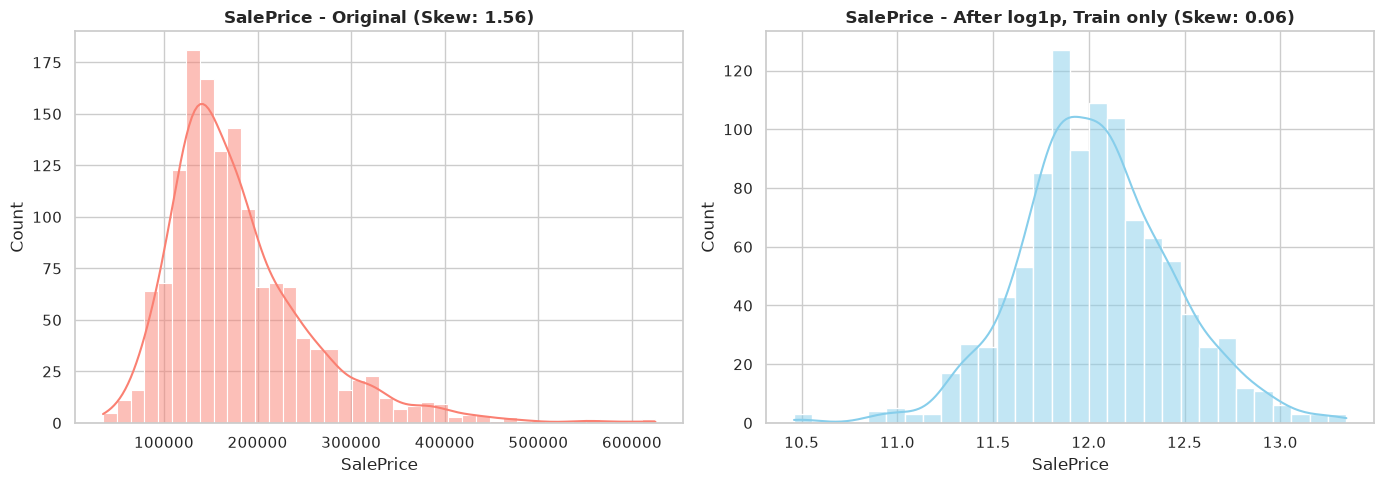

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_model["SalePrice"], kde=True, color="salmon", ax=axes[0])
axes[0].set_title(f"SalePrice - Original (Skew: {skew(df_model['SalePrice']):.2f})", fontweight="bold")
sns.histplot(y_train, kde=True, color="skyblue", ax=axes[1])
axes[1].set_title(f"SalePrice - After log1p, Train only (Skew: {skew(y_train):.2f})", fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class SkewCorrector(BaseEstimator, TransformerMixin):
    def _init_(self, skew_threshold=0.75):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        skews = X.apply(lambda col: skew(col.astype(float)))
        self.skewed_cols_ = skews[abs(skews) > self.skew_threshold].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.skewed_cols_:
            X[col] = np.log1p(X[col].clip(lower=0))
        return X.values

In [29]:
ordinal_categories = {
    "ExterQual":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":   ["Po", "Fa", "TA", "Gd", "Ex"],  
    "BsmtQual":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual":  ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":  ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC":      ["None", "Fa", "TA", "Gd", "Ex"],
    "LotShape":    ["IR3", "IR2", "IR1", "Reg"],
    "Utilities":   ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}
ordinal_category_list = [ordinal_categories[c] for c in ordinal_features]

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# Pipeline 1 — Numerical
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("skew_fix", SkewCorrector(skew_threshold=0.75)),
    ("scaler", RobustScaler()),
])

# Pipeline 2 — Nominal categorical
nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Pipeline 3 — Ordinal categorical
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("ordinal_enc", OrdinalEncoder(
        categories=ordinal_category_list,
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )),
])

In [51]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("nom", nominal_pipeline, nominal_features),
    ("ord", ordinal_pipeline, ordinal_features),
], remainder="drop")

In [52]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

svr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="rbf", C=10, epsilon=0.01)),
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])

In [53]:
svr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(pipeline, X, y_true_log, name):
    y_pred_log = pipeline.predict(X)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"MAE:  ${mae:,.0f}")
    print(f"R2:   {r2:.4f}\n")
    return rmse, mae, r2

svr_metrics = evaluate(svr_pipeline, X_val, y_val, "SVR (Validation)")
rf_metrics = evaluate(rf_pipeline, X_val, y_val, "Random Forest (Validation)")

--- SVR (Validation) ---
RMSE: $25,134
MAE:  $18,006
R2:   0.8825

--- Random Forest (Validation) ---
RMSE: $25,452
MAE:  $17,679
R2:   0.8796



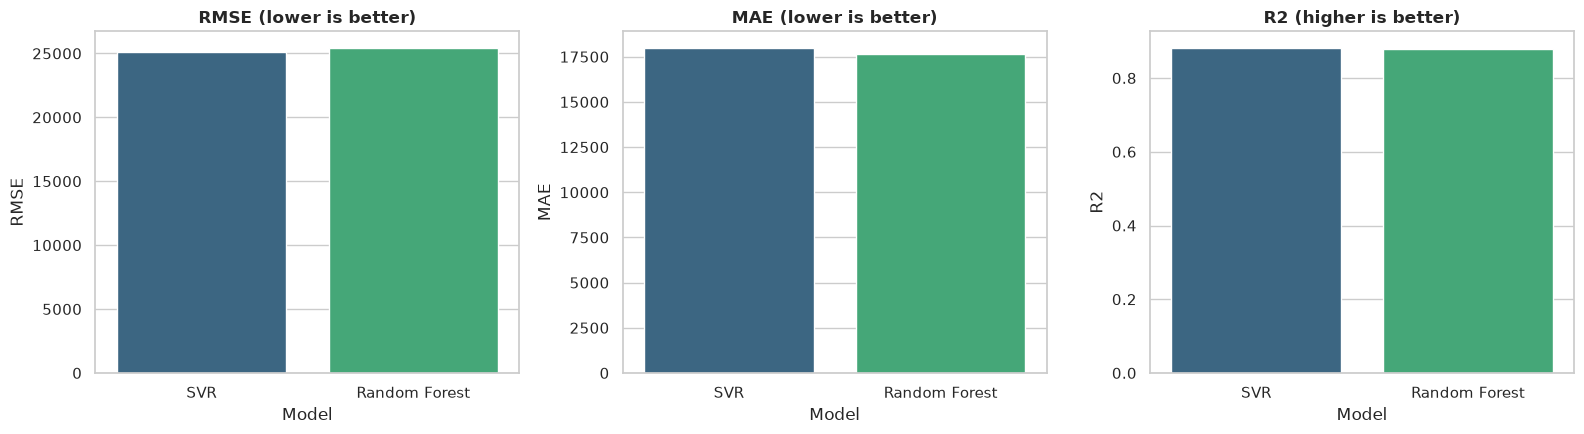

,Model,RMSE,MAE,R2
0,SVR,25133.704349,18006.081254,0.882549
1,Random Forest,25452.234562,17679.292095,0.879553


In [55]:
results = pd.DataFrame({
    "Model": ["SVR", "Random Forest"],
    "RMSE": [svr_metrics[0], rf_metrics[0]],
    "MAE": [svr_metrics[1], rf_metrics[1]],
    "R2": [svr_metrics[2], rf_metrics[2]],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=results, x="Model", y="RMSE", hue="Model", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("RMSE (lower is better)", fontweight="bold")
sns.barplot(data=results, x="Model", y="MAE", hue="Model", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("MAE (lower is better)", fontweight="bold")
sns.barplot(data=results, x="Model", y="R2", hue="Model", palette="viridis", legend=False, ax=axes[2])
axes[2].set_title("R2 (higher is better)", fontweight="bold")
plt.tight_layout()
plt.show()

results

In [56]:
# --- check nulls BEFORE preprocessing ---
print("Missing values in X_train (raw):", X_train.isnull().sum().sum())

Missing values in X_train (raw): 5444


In [57]:
# --- fit the preprocessor and transform ---
X_train_transformed = preprocessor.fit_transform(X_train)

import numpy as np
print("Missing values in X_train (after ColumnTransformer):", np.isnan(X_train_transformed).sum())

Missing values in X_train (after ColumnTransformer): 0


In [58]:
# --- Get the fitted numerical pipeline out of the ColumnTransformer ---
fitted_preprocessor = svr_pipeline.named_steps["preprocessor"]
fitted_num_pipeline = fitted_preprocessor.named_transformers_["num"]
skew_fix_step = fitted_num_pipeline.named_steps["skew_fix"]


skewed_col_indices = skew_fix_step.skewed_cols_
skewed_cols = [numerical_features[i] for i in skewed_col_indices]

print("Columns transformed with log1p:", skewed_cols)

Columns transformed with log1p: ['GrLivArea', 'LotArea', '1stFlrSF', '2ndFlrSF', 'LotFrontage', 'MasVnrArea']


In [59]:
# --- Rebuild transformed numerical data 
X_train_num_transformed = fitted_preprocessor.transform(X_train)[:, :len(numerical_features)]
X_train_num_df = pd.DataFrame(X_train_num_transformed, columns=numerical_features)

X_train_num_df.head()

,GrLivArea,LotArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,GarageArea,LotFrontage,MasVnrArea,YearBuilt,YearRemodAdd,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,MoSold,YrSold
0,-0.761024,-0.300896,0.071856,-0.105113,0.000000,-2.082430,-0.532232,0.958528,0.063158,-0.432432,0.0,0.0,0.0,-0.5,-1.0,-2.0,0.666667,0.5
1,0.640143,0.513882,-0.391218,0.141265,1.015796,0.234273,1.098735,0.000000,0.042105,-0.459459,0.0,1.0,0.0,1.0,0.0,0.0,1.666667,-0.5
2,-1.293279,-0.180311,-0.375250,-0.648003,0.000000,-0.832972,-0.112105,0.000000,-0.778947,-0.972973,-1.0,0.0,-1.0,-1.5,0.0,-1.0,-0.333333,0.5
3,0.266678,0.248409,-0.409182,-0.618037,1.020595,0.303688,-1.795639,0.000000,0.442105,0.054054,0.0,1.0,0.0,0.0,0.0,0.0,-0.666667,0.5
4,0.265356,0.139803,1.309381,0.941776,0.000000,0.086768,0.796105,1.177247,0.652632,0.324324,0.0,0.0,0.0,1.0,0.0,0.0,-0.333333,-1.0


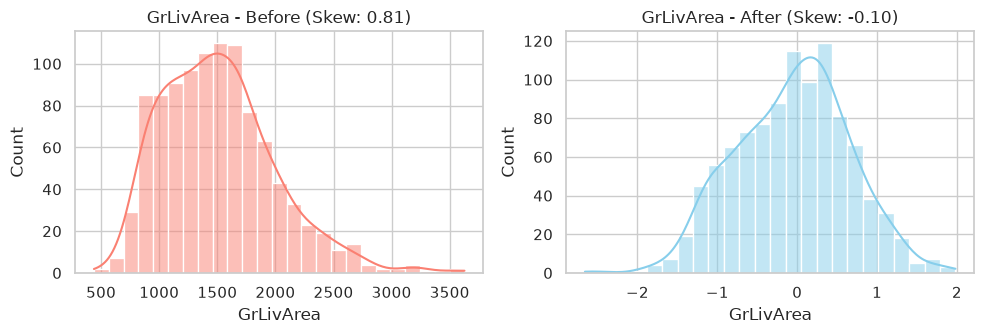

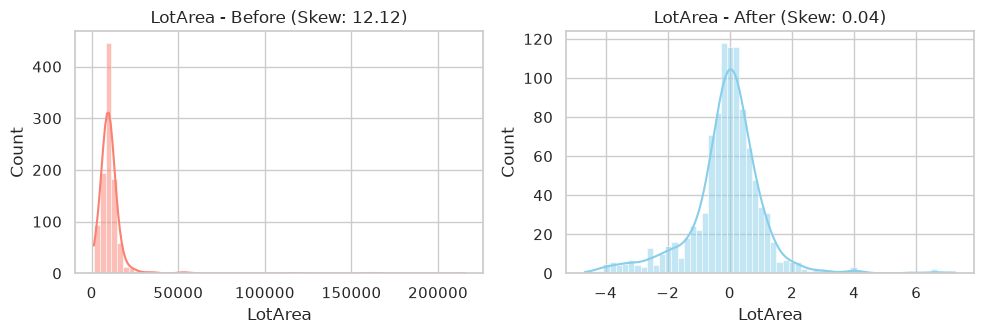

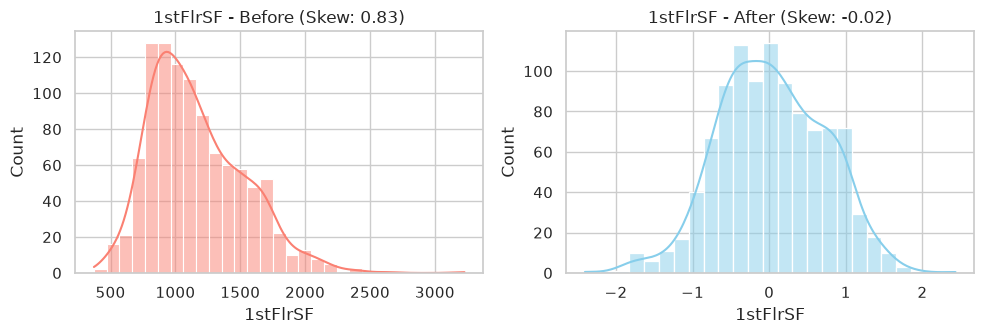

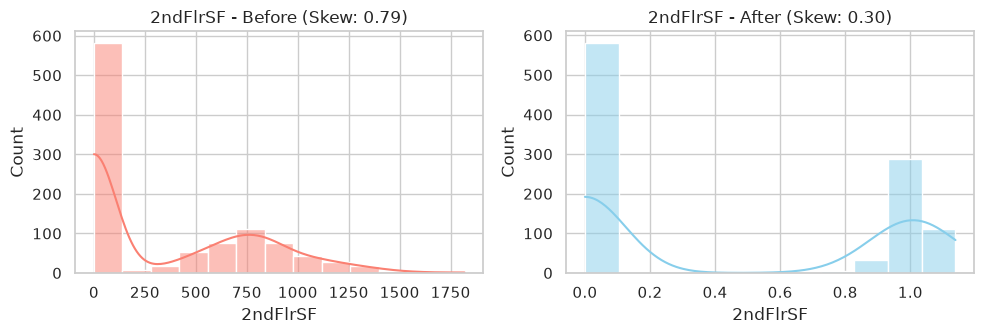

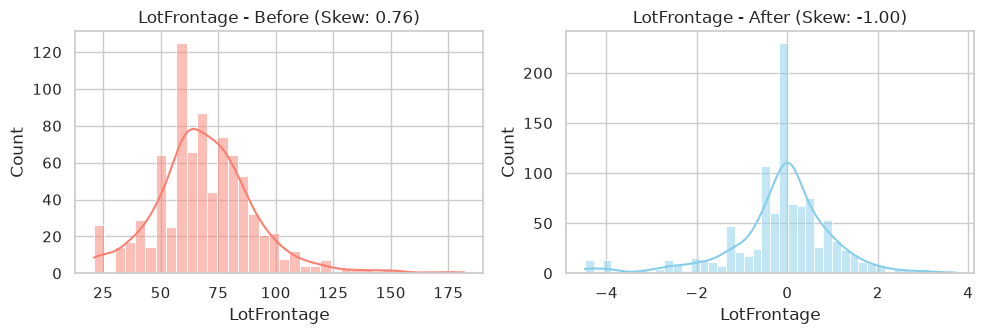

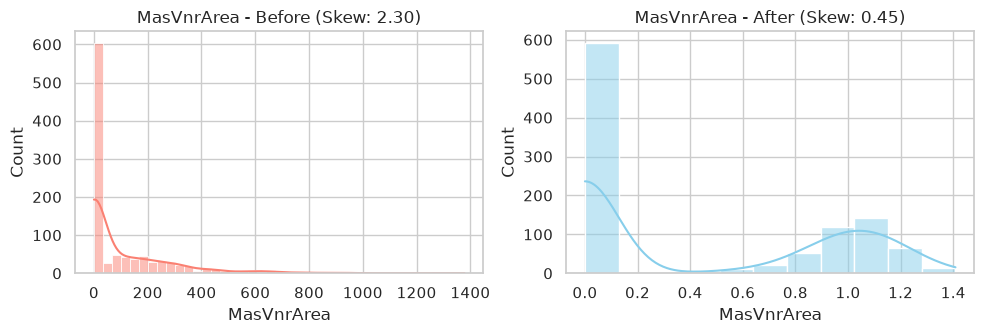

In [60]:
# --- Plot before vs after
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

for col in skewed_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    sns.histplot(X_train[col].dropna(), kde=True, color="salmon", ax=axes[0])
    axes[0].set_title(f"{col} - Before (Skew: {skew(X_train[col].dropna()):.2f})")

    sns.histplot(X_train_num_df[col], kde=True, color="skyblue", ax=axes[1])
    axes[1].set_title(f"{col} - After (Skew: {skew(X_train_num_df[col]):.2f})")

    plt.tight_layout()
    plt.show()

In [42]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from xgboost import XGBRegressor

# 1. Log-transform target variable to handle high skewness (1.88)
y = np.log1p(df["SalePrice"])
X = df.drop(columns=["SalePrice", "Id"])

# 2. Define Feature Preprocessing Pipelines
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])

nominal_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

ordinal_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("nom", nominal_pipeline, nominal_features),
        ("ord", ordinal_pipeline, ordinal_features),
    ]
)

# 3. Full Model Pipeline with XGBoost
model_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(random_state=42, objective="reg:squarederror")),
    ]
)

# 4. Hyperparameter Search Space
param_distributions = {
    "regressor__n_estimators": [100, 300, 500, 800],
    "regressor__max_depth": [3, 5, 7, 9],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__colsample_bytree": [0.4, 0.6, 0.8, 1.0],
    "regressor__reg_alpha": [0, 0.1, 1, 10],  # L1 regularization
    "regressor__reg_lambda": [0.1, 1, 5, 10],  # L2 regularization
}

# 5. Randomized Search CV
search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# 6. Fit and Output Best Hyperparameters
search.fit(X, y)

print(f"Best RMSE Score: {-search.best_score_:.4f}")
print("Best Hyperparameters:")
for param, val in search.best_params_.items():
    print(f"  {param.replace('regressor__', '')}: {val}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RMSE Score: 0.1415
Best Hyperparameters:
  subsample: 1.0
  reg_lambda: 1
  reg_alpha: 0
  n_estimators: 800
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.4


In [65]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Get best model from search
best_model = search.best_estimator_

# 2. Predict on Test Set (in log scale)
y_test_pred_log = best_model.predict(X_test)

# 3. Calculate Log-RMSE (Kaggle Metric)
test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))

# 4. Convert back to original Dollar Scale for actual price error
y_test_true_dollars = np.expm1(y_test)
y_test_pred_dollars = np.expm1(y_test_pred_log)

test_mae = mean_absolute_error(y_test_true_dollars, y_test_pred_dollars)
test_r2 = r2_score(y_test_true_dollars, y_test_pred_dollars)

# 5. Print Results
print("--- Final Hold-Out Test Results ---")
print(f"Test Log-RMSE : {test_rmse_log:.4f}")
print(f"Test MAE ($)  : ${test_mae:,.2f}")
print(f"Test R² Score : {test_r2:.4f}")

--- Final Hold-Out Test Results ---
Test Log-RMSE : 0.0669
Test MAE ($)  : $8,446.11
Test R² Score : 0.9707


/tmp/ipykernel_27898/1545686111.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


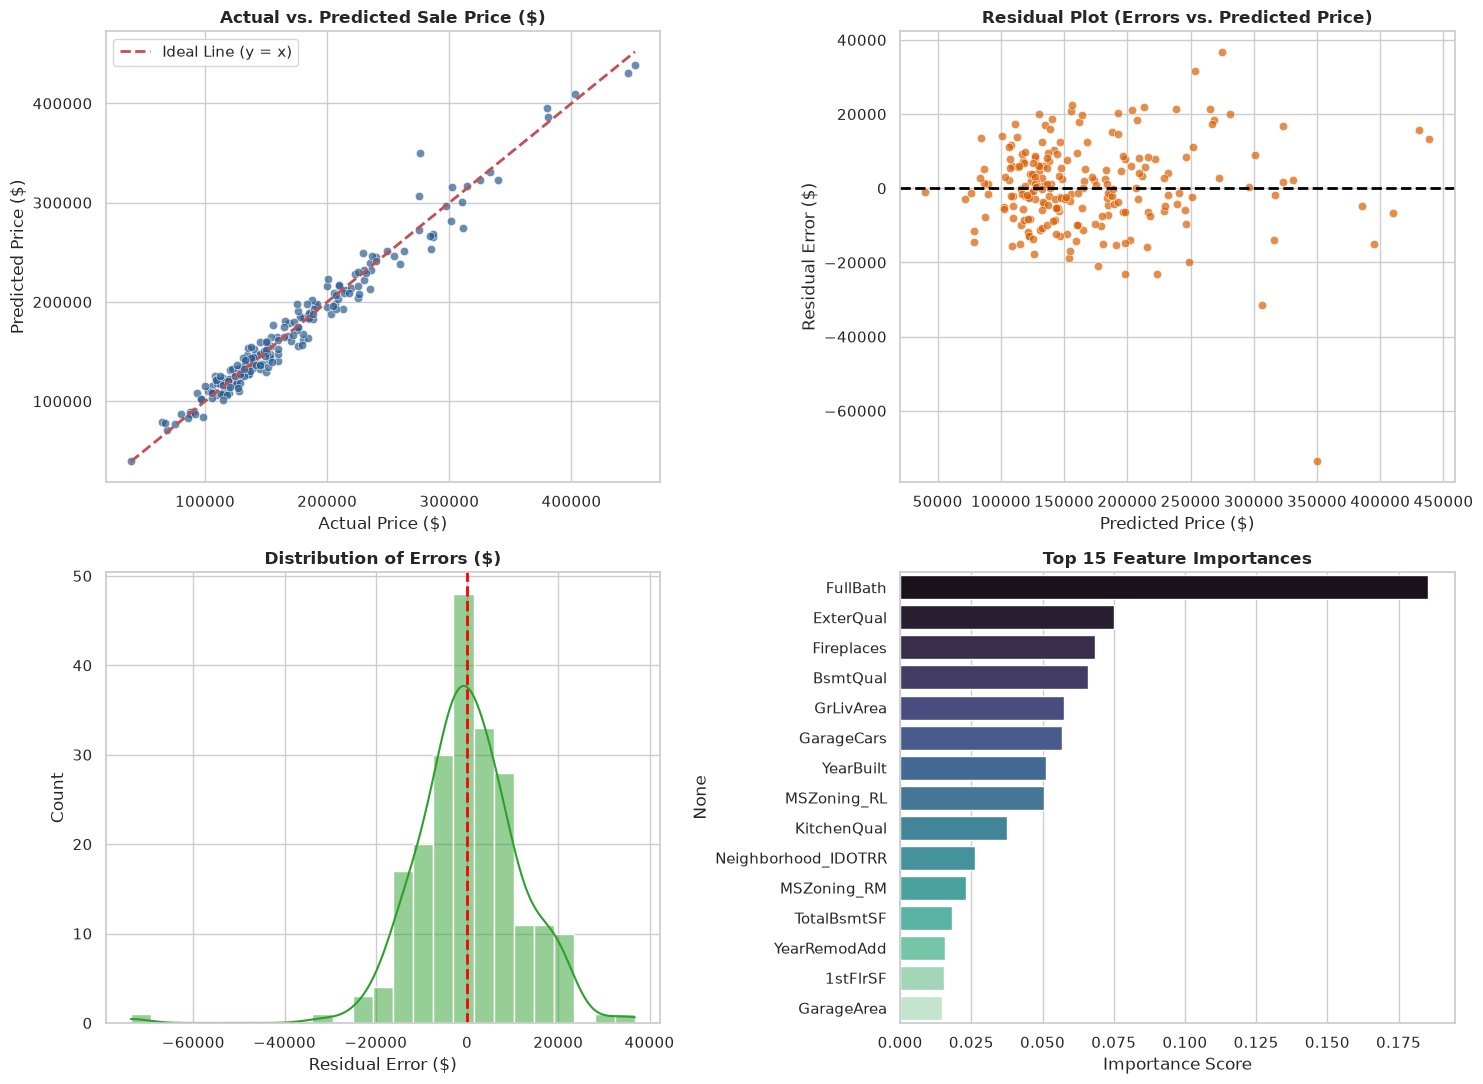

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Convert predictions and true targets back to actual dollar amounts
y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(best_model.predict(X_test))
residuals = y_true_dollars - y_pred_dollars

# 1. Actual vs. Predicted Prices
sns.scatterplot(
    x=y_true_dollars,
    y=y_pred_dollars,
    ax=axes[0, 0],
    alpha=0.7,
    color="#2b5c8f",
)
min_val, max_val = min(y_true_dollars.min(), y_pred_dollars.min()), max(
    y_true_dollars.max(), y_pred_dollars.max()
)
axes[0, 0].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Ideal Line (y = x)",
)
axes[0, 0].set_title(
    "Actual vs. Predicted Sale Price ($)", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Actual Price ($)")
axes[0, 0].set_ylabel("Predicted Price ($)")
axes[0, 0].legend()

# 2. Residual Plot (Errors vs Predicted)
sns.scatterplot(
    x=y_pred_dollars, y=residuals, ax=axes[0, 1], alpha=0.7, color="#d95f02"
)
axes[0, 1].axhline(0, color="black", linestyle="--", lw=2)
axes[0, 1].set_title(
    "Residual Plot (Errors vs. Predicted Price)", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Predicted Price ($)")
axes[0, 1].set_ylabel("Residual Error ($)")

# 3. Residual Error Distribution
sns.histplot(residuals, kde=True, ax=axes[1, 0], color="#2ca02c", bins=25)
axes[1, 0].axvline(0, color="red", linestyle="--", lw=2)
axes[1, 0].set_title(
    "Distribution of Errors ($)", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Residual Error ($)")

# 4. Top 15 Feature Importances
try:
    feature_names = best_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()
    importances = best_model.named_steps["regressor"].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(
        ascending=False
    )[:15]
    feat_imp.index = [col.split("__")[-1] for col in feat_imp.index]

    sns.barplot(
        x=feat_imp.values, y=feat_imp.index, ax=axes[1, 1], palette="mako"
    )
    axes[1, 1].set_title(
        "Top 15 Feature Importances", fontsize=12, fontweight="bold"
    )
    axes[1, 1].set_xlabel("Importance Score")
except Exception:
    axes[1, 1].text(
        0.5,
        0.5,
        "Feature importances unavailable",
        ha="center",
        va="center",
    )

plt.tight_layout()
plt.show()